In [ ]:
import pandas as pd
import numpy as np
import warnings

from sklearn.dummy import DummyRegressor
from skforecast.recursive import ForecasterRecursive
from skforecast.recursive import ForecasterEquivalentDate
from skforecast.exceptions import IgnoredArgumentWarning

import seaborn as sns
sns.set_theme(palette="colorblind")

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)      

# Load data

Data file to be downloaded [here](https://otexts.com/fpppy/data/algeria_exports.csv).

In [2]:
df = pd.read_csv("algeria_exports.csv", parse_dates=["ds"], index_col="ds", usecols=["ds", "y"])

# explicitly set the frequency of the index to yearly
df.index.freq = 'YE'

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 58 entries, 1960-12-31 to 2017-12-31
Freq: YE-DEC
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       58 non-null     float64
dtypes: float64(1)
memory usage: 928.0 bytes


# Naive Baselines

In [3]:
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import backtesting_forecaster
from sklearn.metrics import root_mean_squared_error

cv = TimeSeriesFold(
         steps=1, # =forecast horizon
         initial_train_size=40, # size of the initial training set
         refit=False, # if true, the forecaster is refitted at each fold
         fixed_train_size=False # fixed-size or expanding training data
     )

## Mean baseline

In [4]:
mean_forecaster = ForecasterRecursive(estimator=DummyRegressor(strategy='mean'), lags=1)

results, predictions_backtest = backtesting_forecaster(
                                   forecaster=mean_forecaster,
                                   y=df['y'],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results

  0%|          | 0/18 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
0,13.679622,12.150722


## Last-value baseline

In [5]:
last_value_forecaster = ForecasterEquivalentDate(offset=1, n_offsets=1)

results, predictions_backtest = backtesting_forecaster(
                                   forecaster=last_value_forecaster,
                                   y=df['y'],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results

  0%|          | 0/18 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
0,5.514155,4.007343


# Simple Exponential Smoothing

In [6]:
from skforecast.stats._ets import Ets
from skforecast.recursive import ForecasterStats
from skforecast.model_selection._validation import backtesting_stats

<Axes: >

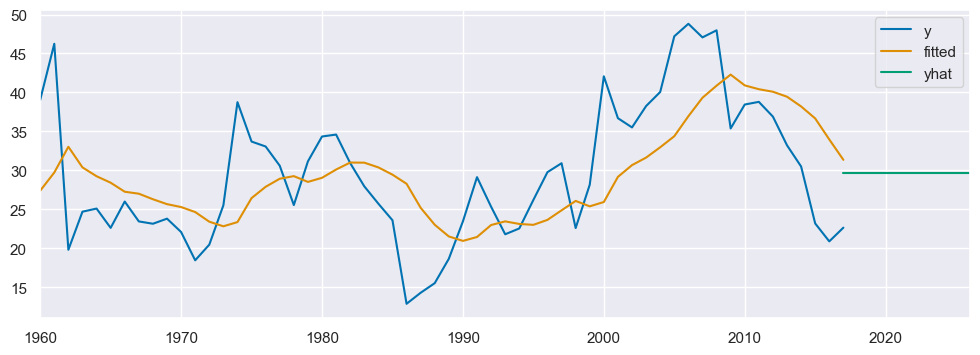

In [7]:
# "ANN" for Simple Exponential Smoothing
# "AAN" for Holt's Additive method
# "AAA" for Holt-Winters' Additive method
# "AAM" for Holt-Winters' Multiplicative method
model = Ets(model='ANN', alpha=0.2)
model.fit(y=df['y'])

# values fitted on the full dataset
fitted = model.fitted_values_

# predicted values 10 steps at the end of the dataset
predictions = pd.DataFrame({"yhat": model.predict(steps=10)}, 
                           index=pd.date_range(start=df.index[-1], periods=10, freq='YE'))

# plot original series, SES-fitted values and predictions
tdf = pd.DataFrame({"y": df['y'], "fitted": fitted})
tdf = tdf.merge(predictions, left_index=True, right_index=True, how='outer')
tdf.plot(figsize=(12,4))

In [8]:
# backtesting

ets_forecaster = ForecasterStats(estimator=Ets(alpha=0.2, model='ANN'))

results, predictions_backtest = backtesting_stats(
                                   forecaster=ets_forecaster,
                                   y=df['y'],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results

  0%|          | 0/18 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
0,8.960974,8.068408


<Axes: >

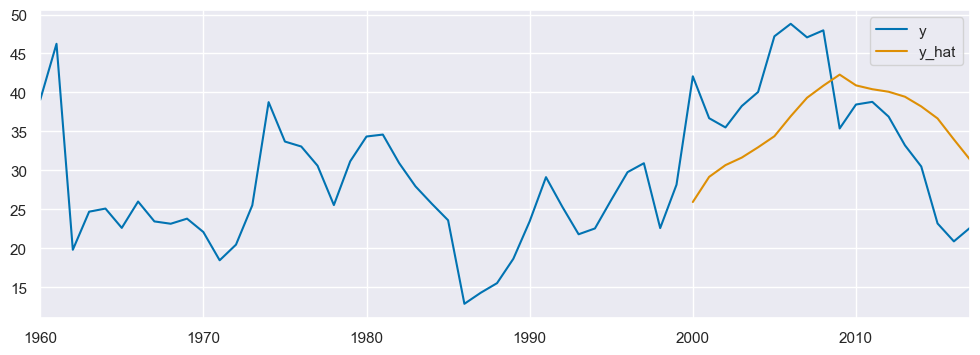

In [9]:
tdf = pd.DataFrame({"y": df['y'], "y_hat": predictions_backtest['pred']})
tdf.plot(figsize=(12,4))

# AutoETS

In [10]:
model = Ets(model=None)
model.fit(y=df['y'])

,m,1
,model,'ZZZ'
,damped,None
,alpha,None
,beta,None
,gamma,None
,phi,None
,seasonal,True
,trend,None
,allow_multiplicative,True
,allow_multiplicative_trend,False


In [11]:
model.best_params_

{'m': 1,
 'model': 'MAN',
 'damped': True,
 'alpha': np.float64(0.9947732582501452),
 'beta': np.float64(0.00010000000000735809),
 'gamma': 0.0,
 'phi': np.float64(0.8000000000000025),
 'lambda_param': None,
 'lambda_auto': False,
 'bias_adjust': True,
 'bounds': 'both',
 'seasonal': True,
 'trend': None,
 'ic': 'aicc',
 'allow_multiplicative': True,
 'allow_multiplicative_trend': False}

<Axes: >

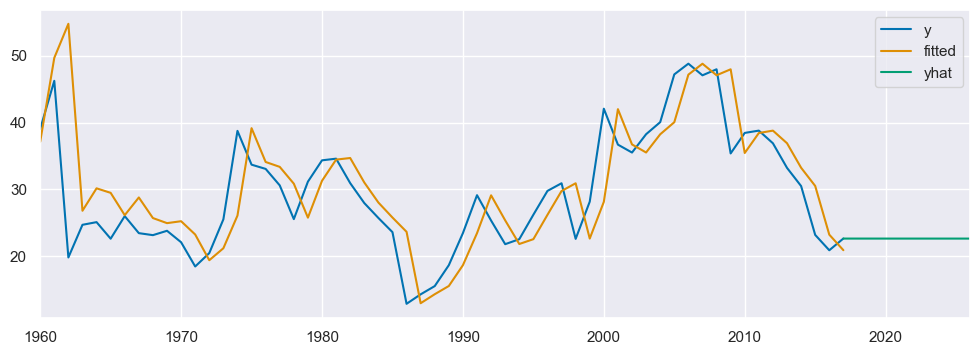

In [12]:
# values fitted on the full dataset
fitted = model.fitted_values_

# predicted values 10 steps at the end of the dataset
predictions = pd.DataFrame({"yhat": model.predict(steps=10)}, 
                           index=pd.date_range(start=df.index[-1], periods=10, freq='YE'))

# plot original series, AutoETS-fitted values and predictions
tdf = pd.DataFrame({"y": df['y'], "fitted": fitted})
tdf = tdf.merge(predictions, left_index=True, right_index=True, how='outer')
tdf.plot(figsize=(12,4))

In [13]:
# backtesting

ets_forecaster = ForecasterStats(estimator=Ets(model=None))

results, predictions_backtest = backtesting_stats(
                                   forecaster=ets_forecaster,
                                   y=df['y'],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results

  0%|          | 0/18 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
0,5.668744,4.257416


# Citing this notebook

If you use this notebook in your work, please cite it as follows:

Pekar, V. (2026). Business Forecasting. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bf